In [5]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [6]:
df = pd.read_csv('train.csv')
df.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
%pip install ydata_profiling

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Titanic Report")
# profile.to_notebook_iframe()


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['Survived']),df['Survived'],)

In [ ]:
from preprocessing import Formatter

# X_test["Title"] = X_test["Name"].str.extract(r',\s*([^\.]+)\.')

# allowed_titles = ["Mr", "Mrs", "Miss", "Master"]

# X_test["Title"] = X_test["Title"].apply(
#     lambda x: x if x in allowed_titles else "Rare"
# )

# X_test.drop(columns=['Ticket','Cabin','PassengerId','Name'], inplace=True)


In [ ]:
X_train.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
874,875,2,"Abelson, Mrs. Samuel (Hannah Wizosky)",female,28.0,1,0,P/PP 3381,24.0000,NaN,C
154,155,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,NaN,S
388,389,3,"Sadlier, Mr. Matthew",male,NaN,0,0,367655,7.7292,NaN,Q
538,539,3,"Risien, Mr. Samuel Beard",male,NaN,0,0,364498,14.5000,NaN,S
826,827,3,"Lam, Mr. Len",male,NaN,0,0,1601,56.4958,NaN,S


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 408 to 419
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  668 non-null    int64  
 1   Pclass       668 non-null    int64  
 2   Name         668 non-null    object 
 3   Sex          668 non-null    object 
 4   Age          541 non-null    float64
 5   SibSp        668 non-null    int64  
 6   Parch        668 non-null    int64  
 7   Ticket       668 non-null    object 
 8   Fare         668 non-null    float64
 9   Cabin        156 non-null    object 
 10  Embarked     667 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 62.6+ KB


In [ ]:
# X_checkqq = Formatter(X_train)

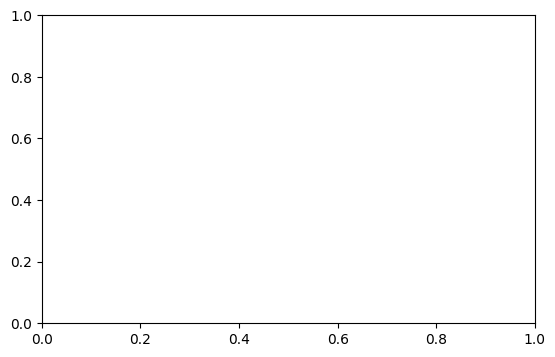

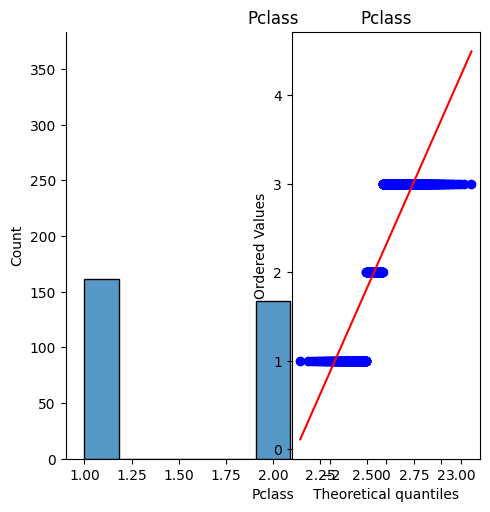

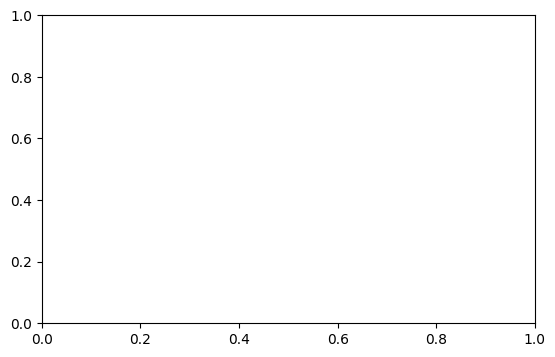

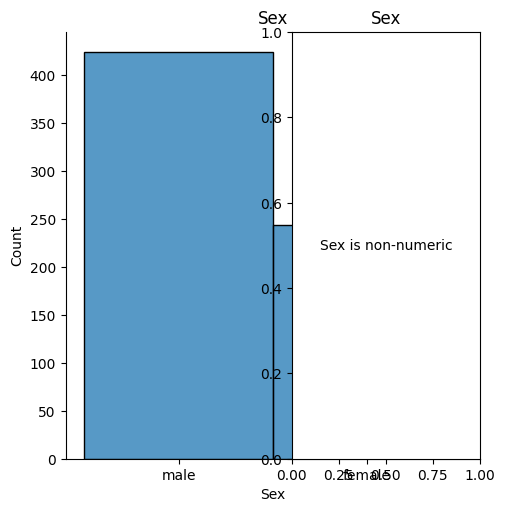

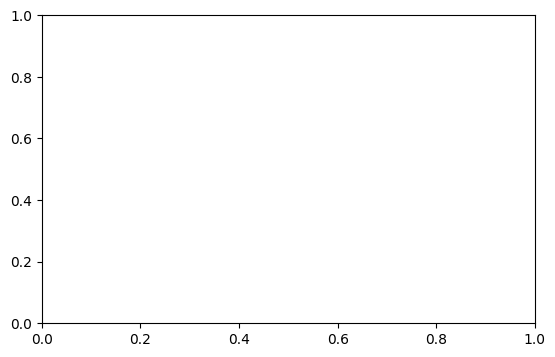

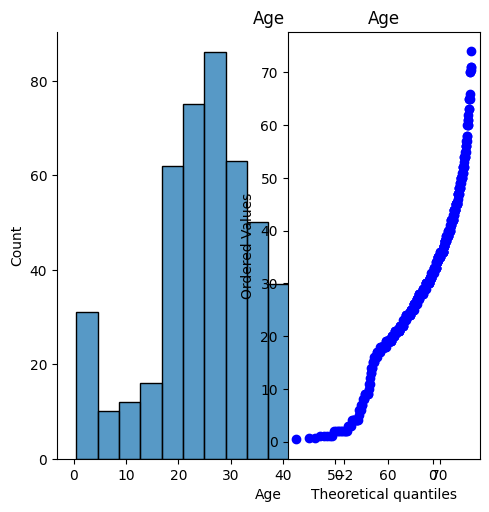

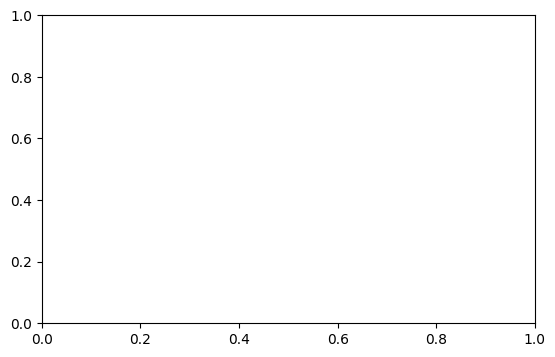

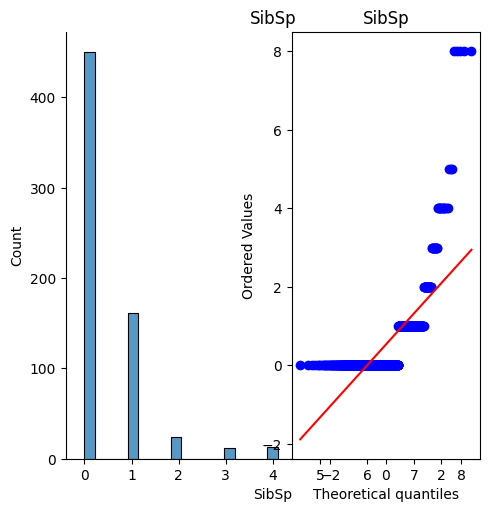

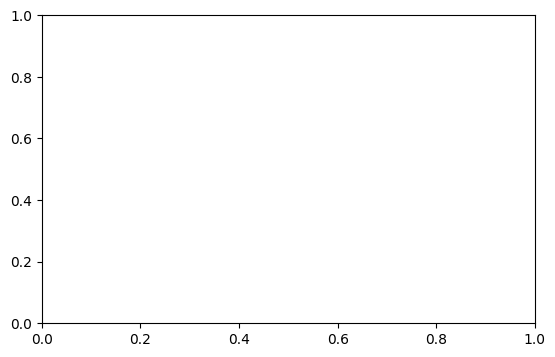

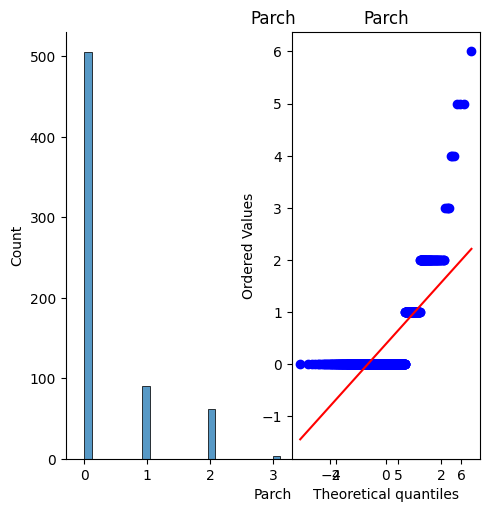

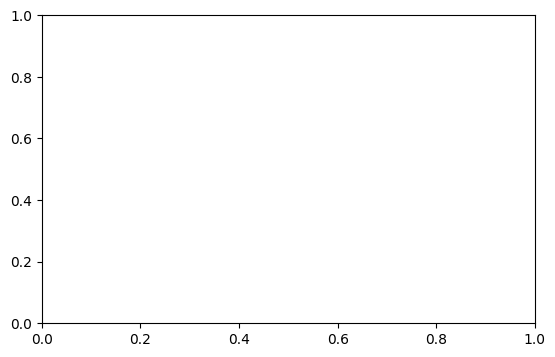

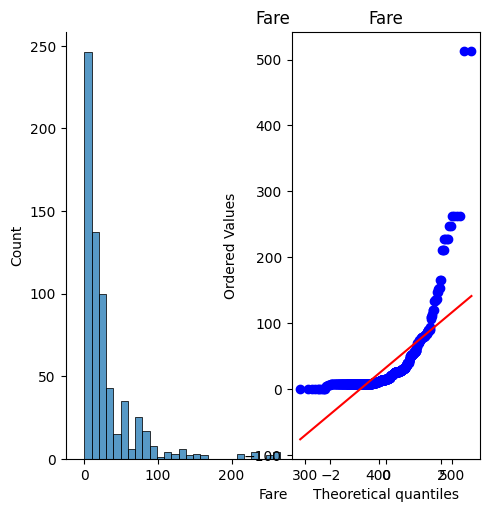

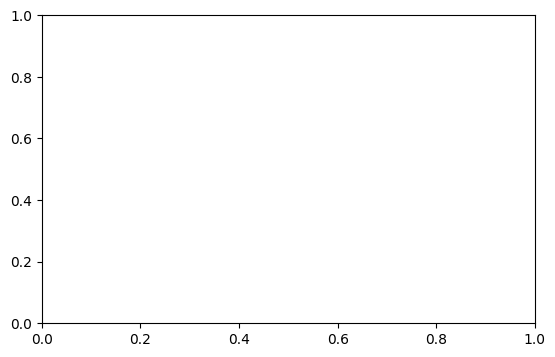

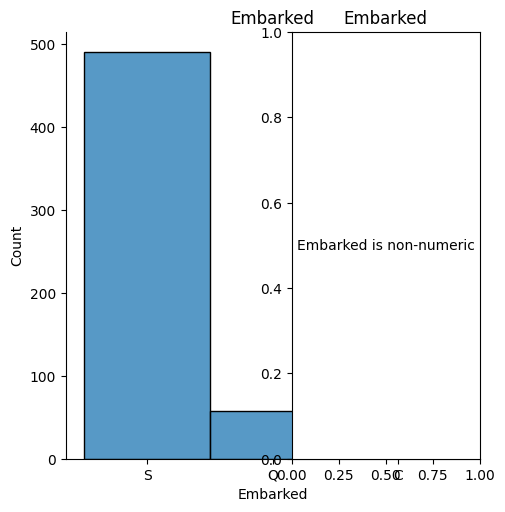

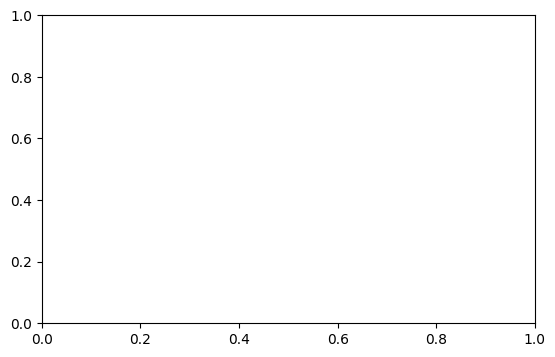

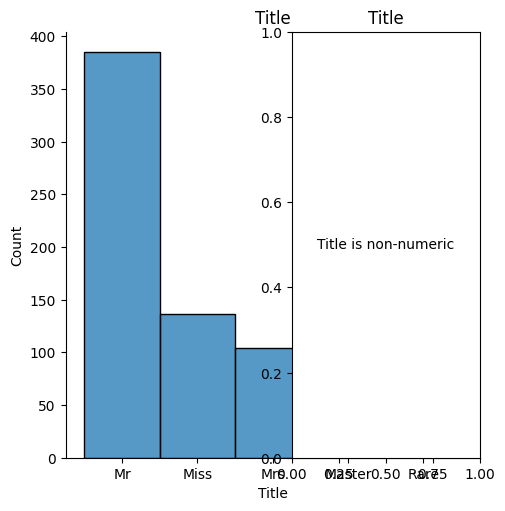

In [ ]:
# import scipy.stats as stats
# import seaborn as sns
# for col in X_checkqq.columns:
#     plt.figure(figsize=(14,4))
#     plt.subplot(121)
#     sns.displot(X_checkqq[col])
#     plt.title(col)
#     plt.subplot(122)
#     if pd.api.types.is_numeric_dtype(X_checkqq[col]):
#         stats.probplot(X_checkqq[col], dist="norm", plot=plt)
#     else:
#         plt.text(0.5, 0.5, f'{col} is non-numeric', ha='center', va='center')
#     plt.title(col)
#     plt.show()

In [ ]:
# transformers
# a function transformer too for better

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer



tnf1 = FunctionTransformer(Formatter, validate=False)

In [ ]:
# filling missing values simpole imputer


tnf2 = ColumnTransformer([
    ('Filling_Missing_Ages',SimpleImputer(strategy="median"),[2]),
    ('Filling_Missing_Ebarked',SimpleImputer(strategy='most_frequent'),[6])
    ],remainder='passthrough')

In [ ]:
categorical_nominal_cols = [1, 3, 7]

tnf3 = ColumnTransformer([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore',sparse_output=False), categorical_nominal_cols)
], remainder='passthrough')


In [ ]:
# scaling
tnf4 = ColumnTransformer([
    ('scale', StandardScaler(), slice(0, -1)) # Scales everything except maybe the final column if needed
], remainder='passthrough')

In [ ]:
from sklearn.linear_model import LogisticRegression


tnf5 = LogisticRegression(max_iter=2000)

In [ ]:
from sklearn.pipeline import Pipeline


pipe = Pipeline([
    ('tnf1',tnf1),
    ('tnf2',tnf2),
    ('tnf3',tnf3),
    ('tnf4',tnf4),
    ('tnf5',tnf5)
])

In [ ]:
pipe.named_steps

{'tnf1': FunctionTransformer(func=<function Formatter at 0x0000015EDD323600>),
 'tnf2': ColumnTransformer(remainder='passthrough',
                   transformers=[('Filling_Missing_Ages',
                                  SimpleImputer(strategy='median'), [2]),
                                 ('Filling_Missing_Ebarked',
                                  SimpleImputer(strategy='most_frequent'),
                                  [6])]),
 'tnf3': ColumnTransformer(remainder='passthrough',
                   transformers=[('onehot',
                                  OneHotEncoder(drop='first',
                                                handle_unknown='ignore',
                                                sparse_output=False),
                                  [1, 3, 7])]),
 'tnf4': ColumnTransformer(remainder='passthrough',
                   transformers=[('scale', StandardScaler(),
                                  slice(0, -1, None))]),
 'tnf5': LogisticRegression(max_iter=200

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 668 entries, 123 to 294
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  668 non-null    int64  
 1   Pclass       668 non-null    int64  
 2   Name         668 non-null    object 
 3   Sex          668 non-null    object 
 4   Age          533 non-null    float64
 5   SibSp        668 non-null    int64  
 6   Parch        668 non-null    int64  
 7   Ticket       668 non-null    object 
 8   Fare         668 non-null    float64
 9   Cabin        149 non-null    object 
 10  Embarked     666 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 62.6+ KB


In [ ]:
pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tnf1', ...), ('tnf2', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function For...0015EDD323600>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to f

In [ ]:
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0])

In [ ]:
from sklearn import set_config


set_config(display='diagram')

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

accuracy_score(y_pred,y_test)

0.7847533632286996

In [ ]:
cross_val_score(pipe,X_train,y_train,cv=5,scoring='accuracy').mean()

np.float64(0.8277971047020536)

In [ ]:
# gridsearchnow
# Use the exact step name ('classifier') followed by double underscores '__'
from sklearn.model_selection import GridSearchCV


#optimising 
params = {
    'tnf5__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'tnf5__solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)




,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'tnf5__C': [0.01, 0.1, ...], 'tnf5__solver': ['lbfgs', 'liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is al

In [ ]:

print("Best Parameter Combinations:", grid.best_params_)
print("Best Classification Accuracy Score:", grid.best_score_)

Best Parameter Combinations: {'tnf5__C': 0.1, 'tnf5__solver': 'lbfgs'}
Best Classification Accuracy Score: 0.8308046234990462


In [ ]:
y_pred = pipe.predict(X_test)
accuracy_score(y_pred,y_test)

0.7847533632286996

In [ ]:
cross_val_score(pipe,X_train,y_train,cv=5,scoring='accuracy').mean()

np.float64(0.8277971047020536)

In [ ]:
# df2 = pd.read_csv('test.csv')
# df2.sample(5)

In [ ]:
# passenger_ids = df2['PassengerId']
# df2.sample(5)

In [ ]:
# df2.info()
# df2['Fare'].fillna(df2['Fare'].mean(),inplace=True)

In [ ]:
# submission_y = pipe.predict(df2)


In [ ]:
# submission = pd.DataFrame({
#     'PassengerId' : passenger_ids,
#     'Survived' : submission_y
# })

# submission.to_csv('submission_pipeline.csv',index=False)

In [ ]:
import pickle

pickle.dump(pipe,open('model_pipe_app.pkl','wb'))

In [ ]:
from sklearn.utils import estimator_html_repr

html = estimator_html_repr(pipe)

with open("pipeline.html", "w", encoding="utf-8") as f:
    f.write(html)

In [ ]:
print(Formatter.__module__)

preprocessing
